<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex12_Contingency_Tables_3D_and_Logit_Equivalence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA — Exercise 12: Contingency Tables (3D) and the Loglinear↔Logit Bridge

The 12th and final exercise of *01ZLMA — Generalized Linear Methods*. Three-dimensional contingency tables in depth (uniform association, saturated, hierarchical principle), Simpson's paradox, the equivalence between Poisson loglinear models and logistic regression, and a brief introduction to multinomial logistic regression. Lecture chapter 8 + extension.

## Contents
1. [Recap and the rest of the 3D hierarchy](#1-recap-3d)
2. [Worked example: aspirin and ulcers (Lecture Ex. 8.5)](#2-aspirin-ulcers)
3. [Simpson's paradox — kidney stones, Berkeley, Czech census](#3-simpson)
4. [Worked example: drugs (Agresti's classic, full model selection)](#4-drugs)
5. [The Poisson↔Multinomial↔Logit bridge](#5-bridge)
6. [Multinomial logistic regression — a brief introduction](#6-mnlogit)
7. [Your turn](#7-your-turn)
8. [Course summary](#8-course-summary)


<a id="0-setup"></a>
## 0. Setup

In [1]:
import io
import sys
import warnings

import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import MNLogit
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Suppress benign expected warnings on saturated/near-saturated GLM fits and
# pandas groupby/pivot future-warnings. We keep all error-class warnings visible.
warnings.filterwarnings("ignore", message=".*observed=False.*")
warnings.filterwarnings("ignore", message=".*divide by zero encountered.*")
try:
    from statsmodels.tools.sm_exceptions import PerfectSeparationWarning
    warnings.filterwarnings("ignore", category=PerfectSeparationWarning)
except ImportError:
    pass

sns.set_theme(style="whitegrid")
np.random.seed(20260504)


In [2]:
# helpers.py: load it from local file when running outside Colab,
# otherwise fetch the GitHub raw version.
try:
    from helpers import Anova, DiagnosticPlots
except ImportError:
    if "google.colab" in sys.modules:
        import wget
        wget.download(
            "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py",
            "helpers.py",
        )
    else:
        sys.path.insert(0, ".")
    from helpers import Anova, DiagnosticPlots

anova = Anova()


In [3]:
import os

BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"


def load_csv(name: str, sep: str = ",") -> pd.DataFrame:
    """Load a CSV from the project data folder.

    Tries the GitHub raw URL first (Colab path); on a 404 falls back to
    a sibling ``data/`` directory next to the notebook (local path,
    useful when the dataset has been added but not yet pushed).
    """
    r = requests.get(BASE_URL + name, verify=False, timeout=30)
    if r.status_code == 200:
        return pd.read_csv(io.StringIO(r.text), sep=sep)
    local = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data", name)
    if os.path.exists(local):
        return pd.read_csv(local, sep=sep)
    r.raise_for_status()  # surface the original HTTP error


<a id="1-recap-3d"></a>
## 1. Recap and the rest of the 3D hierarchy (Lecture §8.3.2 second half)

### 1.1 What we have so far (from ex11 §6)

For three-way tables indexed by $A$, $B$, $C$ we introduced:

| Model | Formula | Statement |
|---|---|---|
| Mutual independence | $\mu+\alpha+\beta+\gamma$ | $A\perp B\perp C$ |
| Partial independence {AB,C} | $\mu+\alpha+\beta+\gamma+(\alpha\beta)_{ij}$ | $\{A,B\}\perp C$ |
| Conditional independence {AC,BC} | $\mu+\alpha+\beta+\gamma+(\alpha\gamma)_{ik}+(\beta\gamma)_{jk}$ | $A\perp B\mid C$ |

The hierarchy now needs two more entries.


### 1.2 Uniform association {AB, AC, BC}

All three two-way interactions, no three-way:
$$
\log\mu_{ijk} = \mu+\alpha_i+\beta_j+\gamma_k+(\alpha\beta)_{ij}+(\alpha\gamma)_{ik}+(\beta\gamma)_{jk}.
$$
Number of parameters: $KI + KJ + IJ - (I+J+K) + 1$.

**Interpretation.** All three pairs are associated *and* the strength of any two-way association is the *same* in every level of the third factor. There is no effect-modification by the third factor. This sounds restrictive but in fact often fits real data well — the data show no further three-way structure beyond what is explained by the three pairwise relationships.


### 1.3 Saturated {ABC}

All interactions including the three-way:
$$
\log\mu_{ijk} = \mu+\alpha_i+\beta_j+\gamma_k+(\alpha\beta)_{ij}+(\alpha\gamma)_{ik}+(\beta\gamma)_{jk}+(\alpha\beta\gamma)_{ijk}.
$$
$IJK$ parameters; deviance $0$. Reproduces the table exactly.


### 1.4 The hierarchical principle (Lecture Pozn. 8.2)

> **A loglinear model is *hierarchical* iff every higher-order term implies the presence of all its lower-order subset terms.**

Practical consequence: when fitting via `smf.glm`, write `Y ~ A*B*C` (which expands to all $2^3=8$ terms) and prune three-way / two-way terms by **dropping**, not by adding `Y ~ A:B:C` (interaction-only) which is not hierarchical and therefore not a meaningful loglinear model.


### 1.5 Model-selection workflow for 3D tables

1. **Start saturated.** Drop $(\alpha\beta\gamma)_{ijk}$. Test by LRT — if $p$ comfortably exceeds 0.05, the three-way is redundant.
2. **Try dropping each two-way in turn**, always keeping (a) the design-fixed marginals and (b) hierarchy. Whichever drop leaves the model still adequate (deviance $<\chi^2_{0.95}$ on its df) is a candidate to keep dropped.
3. **Iterate.** The simplest model that still adequately fits is the *final* loglinear model.

We work this out concretely on aspirin–ulcers (§2), kidney stones (§3), and drugs (§4).


<a id="2-aspirin-ulcers"></a>
## 2. Worked example: aspirin and ulcers (Lecture Example 8.5)

### 2.1 Recall: case-control design

`aspirin_ulcers.csv` is the lecture's Example 8.3. The design fixes case-control row totals $n_{i\cdot k}$ within each ulcer-type subtable. Hence the **mandatory** parameters are $\mu, \alpha^C, \gamma^U, (\alpha\gamma)^{CU}$. Anything we add to that on top changes the question; anything we *omit* breaks the design.


In [4]:
ulc = load_csv("aspirin_ulcers.csv")
ulc["ulcer"]   = pd.Categorical(ulc.ulcer,   categories=["stomach","duodenal"])
ulc["case"]    = pd.Categorical(ulc.case,    categories=["control","case"])
ulc["aspirin"] = pd.Categorical(ulc.aspirin, categories=["no","yes"])
ulc.pivot_table(index=["ulcer","case"], columns="aspirin", values="counts",
                 aggfunc="sum", margins=True, observed=False)


aspirin            no  yes  All
ulcer    case                  
stomach  control   62    6   68
         case      39   25   64
duodenal control   53    8   61
         case      49    8   57
All               203   47  250

### 2.2 Question 1: does aspirin associate with case-control status, given ulcer type? (Lecture page 151)

Test the model $\{CU, UA\}$ — which keeps the design-mandatory $C \times U$ margin and adds the $U \times A$ interaction, but omits $C \times A$. **What hypothesis does this test?** Conditional independence: $C \perp A \mid U$. Rejection means aspirin use and case-control status remain associated **after conditioning on ulcer type** — there is genuine information about case-status carried by aspirin use beyond what is explained by ulcer type alone.

Lecture reports $D = 17.697$ on 2 df, $p = 1.4\times10^{-4}$ — strongly reject. Aspirin use is differentially common between cases and controls.


In [5]:
m_q1 = smf.glm("counts ~ ulcer*case + ulcer*aspirin", data=ulc,
               family=sm.families.Poisson()).fit()
m_sat = smf.glm("counts ~ ulcer*case*aspirin", data=ulc,
                family=sm.families.Poisson()).fit()
lrt_q1 = m_q1.deviance - m_sat.deviance
df_q1 = m_q1.df_resid - m_sat.df_resid
print(f"D_{{CU,AU}} = {m_q1.deviance:.3f} on {m_q1.df_resid} df")
print(f"p = {st.chi2.sf(m_q1.deviance, m_q1.df_resid):.2e}")


D_{CU,AU} = 17.697 on 2 df
p = 1.44e-04


### 2.3 Question 2: does aspirin associate with ulcer type, given case-control status? (Lecture page 152)

Test the model $\{CU, CA\}$ — which keeps $C \times U$ and adds $C \times A$, but omits $U \times A$. **What hypothesis does this test?** Conditional independence: $U \perp A \mid C$. Rejection means aspirin use and ulcer type remain associated **after conditioning on case-control status** — i.e., the relationship of aspirin use to ulcer type is not fully explained by the case/control status.

Lecture: $D = 10.54$ on 2 df, $p < 0.005$ — also reject. So *both* conditional-independence statements fail; aspirin associates with case-control *and* with ulcer type.

> **Note.** This is a test of conditional association, not of *effect modification*. Effect modification (whether the strength of the aspirin-case-control association *differs* across ulcer types) is the **three-way interaction** $\{CUA\}$, tested in §2.4 below.


In [6]:
m_q2 = smf.glm("counts ~ ulcer*case + case*aspirin", data=ulc,
               family=sm.families.Poisson()).fit()
print(f"D_{{CU,CA}} = {m_q2.deviance:.3f} on {m_q2.df_resid} df")
print(f"p = {st.chi2.sf(m_q2.deviance, m_q2.df_resid):.4f}")


D_{CU,CA} = 10.538 on 2 df
p = 0.0051


### 2.4 Final loglinear model for aspirin–ulcers

Both Q1 and Q2 are rejected, so the model needs both $(\alpha\gamma)^{CA}$ and $(\beta\gamma)^{UA}$ — uniform association. Test of {CU, CA, UA} against the saturated three-way model:


In [7]:
m_unif = smf.glm("counts ~ ulcer*case + case*aspirin + ulcer*aspirin", data=ulc,
                 family=sm.families.Poisson()).fit()
print(f"Uniform association deviance = {m_unif.deviance:.4f} on {m_unif.df_resid} df")
print(f"3-way LRT = {m_unif.deviance:.3f}, p = {st.chi2.sf(m_unif.deviance, m_unif.df_resid):.3f}")


Uniform association deviance = 6.2830 on 1 df
3-way LRT = 6.283, p = 0.012


The 3-way interaction LRT is borderline: $D = 6.28$ on 1 df, $p = 0.012$. **A formal 5% test rejects $\{CU, UA, CA\}$ in favour of the saturated model.** The lecture nevertheless keeps uniform association as the final reported model — it captures all three pairwise associations in compact form, with the residual borderline three-way effect treated as not pedagogically central.

The three uniform-association two-way associations are: $C\times U$ (case-control × ulcer-type, design-mandatory), $C\times A$ (more aspirin use among cases than controls — conditional on ulcer type), and $U\times A$ (aspirin use distribution differs by ulcer type — conditional on case-control status).

Both interpretations should be phrased *conditionally*: "aspirin use is more common among cases than controls, conditional on ulcer type" — case-control studies do not licence causal "aspirin causes ulcers" claims.


<a id="3-simpson"></a>
## 3. Simpson's paradox (Lecture §8.3.3) and Berkeley admissions

\
### 3.1 Kidney stones — the lecture's worked example

Charig et al. (1986) compared two procedures for kidney-stone treatment, recording outcome × method × stone-size. Marginal totals over stone-size:


In [8]:
ks = load_csv("kidney_stones.csv")
ks["size"]    = pd.Categorical(ks["size"],    categories=["small","large"])
ks["method"]  = pd.Categorical(ks["method"],  categories=["A","B"])
ks["outcome"] = pd.Categorical(ks["outcome"], categories=["success","failure"])

# Marginal: collapse over size
marg = ks.pivot_table(index="method", columns="outcome", values="counts", aggfunc="sum",
                       observed=False)
marg["rate"] = (marg.success / marg.sum(axis=1)).round(3)
print("Marginal success rates:")
print(marg)


Marginal success rates:
outcome  success  failure   rate
method                          
A            273       77  0.780
B            289       61  0.826


In [9]:
# Within size
within = ks.pivot_table(index=["size","method"], columns="outcome", values="counts",
                         aggfunc="sum", observed=False)
within["rate"] = (within.success / within.sum(axis=1)).round(3)
print("Within-size success rates:")
print(within)


Within-size success rates:
outcome       success  failure   rate
size  method                         
small A            81        6  0.931
      B           234       36  0.867
large A           192       71  0.730
      B            55       25  0.688


\
### 3.2 The reversal

Method A wins overall conditioning: 93% (small), 73% (large) — both higher than B's 87% and 69%. But marginally, method B wins: 83% vs 78%. **Simpson's paradox.**

The reason: method A was given disproportionately to large-stone patients (the harder cases). Method B's overall numbers are better only because B was given mostly to easy cases.


\
### 3.3 The right loglinear model

Conditional independence {MS, OS} (outcome and method independent given size, plus the design fixity of method-size totals — that's *just* {MS, OS}) explains the data well: within each size class, outcome and method are *not* independent (we already saw method A wins both), so {OS, MS} on its own is not enough. The simplest acceptable model is uniform association {OM, OS, MS}.

The pedagogical point: the *right* analysis is the one that respects the third factor; the *wrong* analysis is the marginal one. Same for Berkeley below.


In [10]:
m_ms_only = smf.glm("counts ~ method*size + outcome", data=ks, family=sm.families.Poisson()).fit()
m_no_om   = smf.glm("counts ~ method*size + outcome*size", data=ks, family=sm.families.Poisson()).fit()
m_unif    = smf.glm("counts ~ method*size + method*outcome + size*outcome", data=ks,
                    family=sm.families.Poisson()).fit()
m_sat     = smf.glm("counts ~ method*size*outcome", data=ks, family=sm.families.Poisson()).fit()
pd.DataFrame({
    "{MS,O}":      [m_ms_only.deviance, m_ms_only.df_resid, m_ms_only.aic],
    "{MS,OS}":     [m_no_om.deviance,   m_no_om.df_resid,   m_no_om.aic],
    "{MS,OS,OM}":  [m_unif.deviance,    m_unif.df_resid,    m_unif.aic],
    "saturated":   [m_sat.deviance,     m_sat.df_resid,     m_sat.aic],
}, index=["deviance","df_resid","AIC"])


,"{MS,O}","{MS,OS}","{MS,OS,OM}",saturated
deviance,33.123949,3.450310,1.008164,-7.993644e-15
df_resid,3.000000,2.000000,1.000000,0.000000e+00
AIC,89.846462,62.172823,61.730678,6.272251e+01


\
### 3.4 When can you collapse a 3D table over a factor?

> **(Bishop, Fienberg, Holland 1975.)** Collapsing over a factor $C$ preserves the association between $A$ and $B$ if and only if $C$ is independent of *at least one* of $A$ and $B$ (conditional on the other).

In kidney stones, size depends on *both* method (assignment was non-random) and outcome (large stones harder). Hence collapsing over size distorts the method–outcome association. **Always check the marginal-vs-conditional pattern before reporting collapsed counts.**


\
### 3.5 Berkeley admissions — Simpson at scale

Bickel et al. (1975) *Science* showed the same effect in UC Berkeley graduate admissions. Marginally, men were admitted at 44.5%, women at 30.4% — a 14-point gap. Conditional on department, the gap closes; women had higher admission rates in 4 of 6 departments. Women applied disproportionately to highly competitive departments.


In [11]:
brk = load_csv("berkeley.csv")
m_marg = brk.groupby(["gender","admit"]).counts.sum().unstack()
m_marg["rate"] = (m_marg.Admitted / m_marg.sum(axis=1)).round(3)
print("Marginal:"); print(m_marg)

m_dept = brk.groupby(["dept","gender","admit"]).counts.sum().unstack()
m_dept["rate"] = (m_dept.Admitted / m_dept.sum(axis=1)).round(3)
print("\nWithin department:"); print(m_dept)


Marginal:
admit   Admitted  Rejected   rate
gender                           
Female       557      1278  0.304
Male        1198      1493  0.445

Within department:
admit        Admitted  Rejected   rate
dept gender                           
A    Female        89        19  0.824
     Male         512       313  0.621
B    Female        17         8  0.680
     Male         353       207  0.630
C    Female       202       391  0.341
     Male         120       205  0.369
D    Female       131       244  0.349
     Male         138       279  0.331
E    Female        94       299  0.239
     Male          53       138  0.277
F    Female        24       317  0.070
     Male          22       351  0.059


In [12]:
# Fit the conditional-independence model: Admit independent of Gender given Department
brk_m = smf.glm("counts ~ dept*gender + dept*admit", data=brk,
                family=sm.families.Poisson()).fit()
brk_unif = smf.glm("counts ~ dept*gender + dept*admit + gender*admit", data=brk,
                   family=sm.families.Poisson()).fit()
print(f"{{D,G}}*{{D,A}} deviance = {brk_m.deviance:.3f} on {brk_m.df_resid} df, p={st.chi2.sf(brk_m.deviance,brk_m.df_resid):.4f}")
print(f"+ G*A: deviance = {brk_unif.deviance:.3f} on {brk_unif.df_resid} df")
lrt_ga = brk_m.deviance - brk_unif.deviance
df_ga = brk_m.df_resid - brk_unif.df_resid
p_ga = st.chi2.sf(lrt_ga, df_ga)
print(f"LRT G*A: {lrt_ga:.3f} on {df_ga} df, p = {p_ga:.4g}")


{D,G}*{D,A} deviance = 21.736 on 6 df, p=0.0014
+ G*A: deviance = 20.204 on 5 df
LRT G*A: 1.531 on 1 df, p = 0.2159


\
The $G \times A$ drop is small **and not statistically significant** ($p \approx 0.22$): once we condition on department, the residual gender-admit association is consistent with chance. The marginal disparity is essentially fully explained by the differential application patterns across departments. **Pedagogical lesson: never report aggregated rates without verifying the conditional pattern** — Simpson's paradox in its cleanest form.


\
### 3.6 Czech 2021 Census call-back — your HW1 in disguise

In your HW1 (ex11 §7) you fit the Czech census `vzdelani × pohlavi × vek` table. Recall:

- 15–64 cohort: women's tertiary share *exceeds* men's
- 65+ cohort: men's tertiary share *exceeds* women's

Aggregating over age would give a misleading marginal answer (depending on which cohort dominates the population), exactly as in kidney stones and Berkeley.

The conditional-independence model {`vzdelani:vek`, `pohlavi:vek`} (`vzdelani` and `pohlavi` independent given `vek`) does *not* fit acceptably for this dataset — education and sex are not conditionally independent given age. The honest model contains `vzdelani:pohlavi` as well — which is uniform association {`vzdelani:vek`, `pohlavi:vek`, `vzdelani:pohlavi`}. The same conceptual lesson as kidney stones and Berkeley: **collapse only when the conditional pattern is genuinely homogeneous across the third factor.**


In [13]:
edu = load_csv("csu_education.csv")
edu["vzdelani"] = pd.Categorical(edu.vzdelani, categories=["ZS","SSnoM","SSM","VS"], ordered=True)
edu["pohlavi"]  = pd.Categorical(edu.pohlavi,  categories=["muz","zena"])
edu["vek"]      = pd.Categorical(edu.vek,      categories=["15-64","65+"])

# Marginal (collapse over age) - sex x education shares
mar = edu.groupby(["vzdelani","pohlavi"]).pocet.sum().unstack().T
mar = mar.div(mar.sum(axis=1), axis=0).round(3)
print("Marginal: education share by sex (collapsed over age):"); print(mar)

# Conditional within age
con = edu.groupby(["vek","vzdelani","pohlavi"]).pocet.sum().unstack().reset_index()
for age, grp in con.groupby("vek"):
    g = grp.set_index("vzdelani")[["muz","zena"]]
    g = g.div(g.sum(axis=0), axis=1).round(3)
    print(f"\nWithin {age}: education share by sex:"); print(g)


Marginal: education share by sex (collapsed over age):
vzdelani     ZS  SSnoM    SSM     VS
pohlavi                             
muz       0.117  0.387  0.304  0.192
zena      0.161  0.275  0.353  0.211

Within 15-64: education share by sex:
pohlavi     muz   zena
vzdelani              
ZS        0.130  0.132
SSnoM     0.356  0.244
SSM       0.316  0.367
VS        0.198  0.258

Within 65+: education share by sex:
pohlavi     muz   zena
vzdelani              
ZS        0.071  0.237
SSnoM     0.499  0.357
SSM       0.260  0.317
VS        0.170  0.089


<a id="4-drugs"></a>
## 4. Worked example: drugs (Agresti's classic, full model selection)

\
### 4.1 The data

Famous teaching dataset (Agresti, *Categorical Data Analysis* page 322): a 1992 survey of 2276 high-school students, recording lifetime use of `alcohol`, `cigarettes`, `marijuana` (each binary). 8 cells.


In [14]:
drugs = load_csv("drugs.txt", sep=";")
for c in ["alcohol","cigarettes","marijuana"]:
    drugs[c] = pd.Categorical(drugs[c], categories=["no","yes"])
drugs.pivot_table(index=["alcohol","cigarettes"], columns="marijuana",
                   values="count", aggfunc="sum", observed=False)


marijuana            no  yes
alcohol cigarettes          
no      no          279    2
        yes          43    3
yes     no          456   44
        yes         538  911

\
### 4.2 Fit the full lattice of hierarchical models

Eight hierarchical models for three binary factors with no design-fixed margins:
mutual indep, three partial-indep variants, three conditional-indep variants, uniform association, saturated. (Plus the empty model, which we skip.)


In [15]:
def fit(formula, df=drugs, response="count"):
    return smf.glm(f"{response} ~ {formula}", data=df, family=sm.families.Poisson()).fit()

models = {
    "mut indep ~A+C+M":     fit("alcohol + cigarettes + marijuana"),
    "{AC,M}":                fit("alcohol*cigarettes + marijuana"),
    "{AM,C}":                fit("alcohol*marijuana + cigarettes"),
    "{CM,A}":                fit("cigarettes*marijuana + alcohol"),
    "{AC,AM}":               fit("alcohol*(cigarettes + marijuana)"),
    "{AC,CM}":               fit("cigarettes*(alcohol + marijuana)"),
    "{AM,CM}":               fit("marijuana*(alcohol + cigarettes)"),
    "uniform {AC,AM,CM}":    fit("(alcohol+cigarettes+marijuana)**2"),
    "saturated {ACM}":       fit("alcohol*cigarettes*marijuana"),
}
table = pd.DataFrame({name: dict(deviance=round(m.deviance,3), df=m.df_resid, aic=round(m.aic,1))
                      for name, m in models.items()}).T
table


,deviance,df,aic
mut indep ~A+C+M,1286.020,4.0,1343.1
"{AC,M}",843.827,3.0,902.9
"{AM,C}",939.563,3.0,998.6
"{CM,A}",534.212,3.0,593.3
"{AC,AM}",497.369,2.0,558.4
"{AC,CM}",92.018,2.0,153.1
"{AM,CM}",187.754,2.0,248.8
"uniform {AC,AM,CM}",0.374,1.0,63.4
saturated {ACM},-0.000,0.0,65.0


\
### 4.3 Walking through model selection

**Step 1.** From saturated, drop the three-way: deviance jumps to ~0.374 on 1 df, $p \approx 0.54$. The three-way is *not* needed.

**Step 2.** From uniform association {AC, AM, CM}, try dropping each two-way in turn:


In [16]:
m_unif = models["uniform {AC,AM,CM}"]
for drop_term in ["alcohol:cigarettes", "alcohol:marijuana", "cigarettes:marijuana"]:
    formula_drop = f"(alcohol+cigarettes+marijuana)**2 - {drop_term}"
    m_drop = smf.glm(f"count ~ {formula_drop}", data=drugs, family=sm.families.Poisson()).fit()
    lrt = m_drop.deviance - m_unif.deviance
    print(f"Drop {drop_term!r}: dev={m_drop.deviance:.3f} on {m_drop.df_resid} df, "
          f"LRT={lrt:.3f}, p={st.chi2.sf(lrt, 1):.2e}")


Drop 'alcohol:cigarettes': dev=187.754 on 2 df, LRT=187.380, p=1.19e-42
Drop 'alcohol:marijuana': dev=92.018 on 2 df, LRT=91.644, p=1.04e-21
Drop 'cigarettes:marijuana': dev=497.369 on 2 df, LRT=496.995, p=4.28e-110


\
All three two-way drops are rejected at $p < 10^{-30}$. The final model is **uniform association {AC, AM, CM}** — every pair of substances is associated, with no further three-way structure.


\
### 4.4 Interpretation: pairwise odds ratios

Under uniform association, $\exp((\alpha\beta)_{22})$ is the odds ratio between the two binary factors at *any* level of the third factor. Compute each:


In [17]:
def or_from_unif(model, term):
    coef = model.params[term]
    se = model.bse[term]
    or_pt = np.exp(coef)
    or_lo, or_hi = np.exp(coef - 1.96*se), np.exp(coef + 1.96*se)
    return or_pt, or_lo, or_hi

for term in ["alcohol[T.yes]:cigarettes[T.yes]",
             "alcohol[T.yes]:marijuana[T.yes]",
             "cigarettes[T.yes]:marijuana[T.yes]"]:
    or_pt, or_lo, or_hi = or_from_unif(m_unif, term)
    print(f"OR({term}) = {or_pt:.2f}  95% CI [{or_lo:.2f}, {or_hi:.2f}]")


OR(alcohol[T.yes]:cigarettes[T.yes]) = 7.80  95% CI [5.55, 10.98]
OR(alcohol[T.yes]:marijuana[T.yes]) = 19.81  95% CI [7.97, 49.24]
OR(cigarettes[T.yes]:marijuana[T.yes]) = 17.25  95% CI [12.51, 23.78]


\
### 4.5 Pearson residual check

Uniform association has 1 df residual; the saturated has 0. Pearson residuals on the {AC,AM,CM} fit should be small.


In [18]:
res_p = (drugs["count"].values - m_unif.fittedvalues.values) / np.sqrt(m_unif.fittedvalues.values)
print("Pearson residuals (sorted):")
print(np.sort(res_p).round(3))
print(f"max |r_P| = {np.abs(res_p).max():.3f}")


Pearson residuals (sorted):
[-0.324 -0.092 -0.037 -0.027  0.02   0.029  0.095  0.524]
max |r_P| = 0.524


<a id="5-bridge"></a>
## 5. The Poisson↔Multinomial↔Logit bridge

\
### 5.1 Three valid forms of the same model

On `kidney_stones.csv`, designate `outcome` as the binary response. The same effect of method × size on outcome can be fit by three model forms:

- **(P) Poisson loglinear** of all 8 cell counts on `method*size + method*outcome + size*outcome` (uniform association — all two-way interactions, no three-way).
- **(B) Binomial logit** of `Outcome` on `method + size` (additive — Birch's theorem absorbs the `method:size` interaction into the fixed margins) with row response `(success, failure)`, weighted by row total.
- **(L) Individual-level logistic** of `Outcome` on `method + size` on the un-aggregated 700 rows.

We fit all three and verify they give *the same* method-outcome odds-ratio coefficient.


\
### 5.2 Why they agree — Birch + Agresti Theorem 8.5.1

If $Y_{ijk}\sim\mathrm{Po}(\mu_{ijk})$ and the loglinear model contains $(\beta\gamma)_{jk}^{MS}$ (the size × method interaction — mandatory because method-size totals are fixed by the experimental design), then conditional on $Y_{ij1}+Y_{ij2}=n_{ij\cdot}$ the count $Y_{ij1}$ is binomial. With $\pi_{ij}=\mu_{ij1}/(\mu_{ij1}+\mu_{ij2})$,
$$
\log\frac{\pi_{ij}}{1-\pi_{ij}} = \log\mu_{ij1} - \log\mu_{ij2} = \alpha_1^O - \alpha_2^O + \text{(non-MS terms involving }i,j\text{)}.
$$

The terms involving only method and size — including the $(\beta\gamma)_{jk}^{MS}$ interaction — **cancel** when conditioning on the method-size totals, because they appear identically in numerator and denominator. Under the uniform-association model $\{MS, MO, SO\}$, what remains in the binomial logit is only the *non-MS* parameters: an additive predictor in `method + size`. A `method:size` term would appear in the binomial logit only if the Poisson model also contained the three-way interaction $\{MSO\}$.


In [19]:
# Form (P) — Poisson uniform association on the 8 cells
ks_uniform = smf.glm(
    "counts ~ method*size + method*outcome + size*outcome",
    data=ks, family=sm.families.Poisson()
).fit()

# Form (B) — Binomial logit with rate response.
# Poisson form (P) is uniform association {MS, MO, SO} with no 3-way; the
# corresponding binomial logit is additive in `method` and `size` (no
# method:size interaction in the logit predictor). Birch's theorem fixes
# {MS} margins, so `method:size` is implicit on the loglinear side but is
# not a free term in the binomial logit's linear predictor.
ks_b = ks.pivot_table(index=["method","size"], columns="outcome",
                       values="counts", aggfunc="sum", observed=False).reset_index()
ks_b["total"] = ks_b.success + ks_b.failure
ks_b["p_success"] = ks_b.success / ks_b.total
mod_b = smf.glm("p_success ~ method + size", data=ks_b,
                family=sm.families.Binomial(), freq_weights=ks_b.total).fit()

# Form (L) — individual-level logistic on un-aggregated data
ks_long = ks.loc[ks.index.repeat(ks.counts)].reset_index(drop=True)
ks_long["y"] = (ks_long.outcome == "success").astype(int)
mod_l = smf.glm("y ~ method + size", data=ks_long, family=sm.families.Binomial()).fit()

print("Form (P) Poisson loglinear, method:outcome coefficient:")
print(ks_uniform.params.filter(like="method").filter(like="outcome"))
print("\nForm (B) Binomial logit, method coefficient:")
print(mod_b.params.filter(like="method"))
print("\nForm (L) Individual logit, method coefficient:")
print(mod_l.params.filter(like="method"))


Form (P) Poisson loglinear, method:outcome coefficient:
method[T.B]:outcome[T.failure]    0.357229
dtype: float64

Form (B) Binomial logit, method coefficient:
method[T.B]   -0.357229
dtype: float64

Form (L) Individual logit, method coefficient:
method[T.B]   -0.357229
dtype: float64


\
### 5.3 Numerical verification

The method log-odds-ratio at *small* stones (i.e. `method[T.B]` in form B/L vs the corresponding `method[T.B]:outcome[T.failure]` interaction in form P) should be equal across all three fits.


In [20]:
# Method × outcome log-OR from Poisson form: coefficient of method:outcome
or_p = ks_uniform.params.get("method[T.B]:outcome[T.failure]", None)
# Method log-OR from binomial form: -coefficient of method (because higher = more failure baseline)
or_b = -mod_b.params.get("method[T.B]", None)
or_l = -mod_l.params.get("method[T.B]", None)
print(f"log-OR(method=B vs A on outcome=failure) — Poisson: {or_p:.6f}")
print(f"log-OR(method=B vs A on success=1) — Binomial: {or_b:.6f}")
print(f"log-OR(method=B vs A on success=1) — Individual: {or_l:.6f}")

assert np.allclose([or_p], [or_b], rtol=1e-6), "P vs B disagree"
assert np.allclose([or_b], [or_l], rtol=1e-6), "B vs L disagree"
print("\nAll three forms give the same method log-odds-ratio to rtol=1e-6.")


log-OR(method=B vs A on outcome=failure) — Poisson: 0.357229
log-OR(method=B vs A on success=1) — Binomial: 0.357229
log-OR(method=B vs A on success=1) — Individual: 0.357229

All three forms give the same method log-odds-ratio to rtol=1e-6.


\
### 5.4 Decision table — when to choose which form

| Goal | Choose |
|---|---|
| Estimate the joint structure of all three factors symmetrically (no designated response) | Poisson loglinear |
| Estimate the effect of predictors on a chosen *binary* response, in odds-ratio language | Binomial logistic (rate form, `freq_weights`) |
| Original data is individual-level (one row per observation) and the response is binary | Binomial logistic (individual form) |
| Data in contingency-table form, only one binary response of interest | Either; binomial is simpler and more interpretable |
| Response has more than two unordered categories | Multinomial logistic (next section) |

### 5.5 ⚠ Pitfalls

- ⚠ The Poisson model and Binomial logit give the *same* coefficients **only if** the loglinear model contains the interactions corresponding to fixed margins. Birch's theorem again — drop {MS} from form (P) and the equivalence breaks.
- ⚠ A loglinear model that omits, e.g., {AC} when the response is $A$ corresponds to a constrained logit of $A$, not the standard one.
- ⚠ Re-expressing a contingency-table loglinear analysis as a logit *loses symmetry* — pairs that were treated equally now come in two flavours (response and predictor).


<a id="6-mnlogit"></a>
## 6. Multinomial logistic regression — a brief introduction

\
### 6.1 The model (beyond lecture chapter 8)

For nominal multinomial response $Y \in \{1,\dots,J\}$ (no order), choose category 1 as reference. Then
$$
\log\frac{P(Y=j\mid\mathbf x)}{P(Y=1\mid\mathbf x)} = \mathbf x^\top\boldsymbol\beta_j, \qquad j=2,\dots,J.
$$
$J-1$ logit equations, each like an ordinary binary logit relative to the reference. When $J=2$ this collapses to standard binary logistic regression (ex07/08).


\
### 6.2 Connection to chapter 8

When all predictors are categorical and the response is the multinomial outcome of an individual-level survey, multinomial logit and Poisson loglinear (with the right interactions) are *algebraically equivalent* — Agresti Theorem 8.5.1 generalises directly. The key is "fixed margins go in the model" — Birch's theorem yet again.


\
### 6.3 Worked example — re-bucketed `crabs.csv`

We re-bucket the satellite count from `crabs.csv` (already in `data/`) into 3 nominal classes (none / low / high) and regress on continuous `width`.


In [21]:
crabs = load_csv("crabs.csv")
print(crabs.head())
print(f"\nshape = {crabs.shape}")


   color  spine  width  satell  weight
0      2      3   28.3       8    3.05
1      3      3   22.5       0    1.55
2      1      1   26.0       9    2.30
3      3      3   24.8       0    2.10
4      3      3   26.0       4    2.60

shape = (173, 5)


In [22]:
# Re-bucket satell into 3 classes
def bucket(s):
    if s == 0: return "none"
    if s <= 2: return "low"
    return "high"

crabs["sat_cat"] = crabs.satell.apply(bucket)
crabs["sat_cat"] = pd.Categorical(crabs.sat_cat, categories=["none","low","high"])
print(crabs.sat_cat.value_counts())


sat_cat
high    86
none    62
low     25
Name: count, dtype: int64


> **⚠ Important caveat.** The satellite count `satell` is naturally ordinal (or count) data, and our re-buckets `none < low < high` *do* have a natural ordering. We deliberately ignore that ordering here only to demonstrate the nominal multinomial-logit API. **For substantive modeling of satellite counts, count models (Poisson, Negative Binomial — see ex09/ex10) or ordinal-response models (proportional-odds logit) would usually be more appropriate.** Re-bucketing ordered or count data into nominal classes throws information away and is not generally recommended.


In [23]:
X = sm.add_constant(crabs[["width"]])
y = crabs.sat_cat.cat.codes  # 0=none, 1=low, 2=high
mn = MNLogit(y, X).fit(disp=False)
print(mn.summary().tables[1])


       y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.3389      3.482     -3.256      0.001     -18.164      -4.514
width          0.4037      0.133      3.029      0.002       0.143       0.665
------------------------------------------------------------------------------
       y=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.4227      2.765     -4.854      0.000     -18.843      -8.003
width          0.5276      0.107      4.952      0.000       0.319       0.736


\
### 6.4 Interpretation

Two log-odds equations relative to category `none`:
$$
\log \frac{P(Y=\mathrm{low}\mid \mathbf{x})}{P(Y=\mathrm{none}\mid \mathbf{x})} = \alpha_{\mathrm{low}} + \beta_{\mathrm{low}}\cdot\mathrm{width},
$$
$$
\log \frac{P(Y=\mathrm{high}\mid \mathbf{x})}{P(Y=\mathrm{none}\mid \mathbf{x})} = \alpha_{\mathrm{high}} + \beta_{\mathrm{high}}\cdot\mathrm{width}.
$$

Each $\beta$ coefficient is a log-odds-ratio: increasing `width` by one unit multiplies the relative odds $P(Y=\mathrm{low}\mid\mathbf{x})/P(Y=\mathrm{none}\mid\mathbf{x})$ by $\exp(\beta_{\mathrm{low}})$, and similarly for `high` versus `none`. Predicted probabilities are computed by the multinomial-logit softmax: $P(Y=j\mid\mathbf{x})$ is normalised across categories so that $\sum_j P(Y=j\mid\mathbf{x}) = 1$.


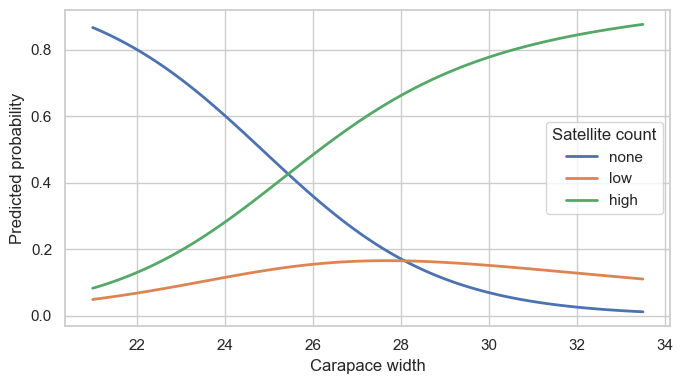

In [24]:
# Predicted probability surface vs width
w = np.linspace(crabs.width.min(), crabs.width.max(), 100)
Xnew = sm.add_constant(pd.DataFrame({"width": w}))
probs = np.asarray(mn.predict(Xnew))  # MNLogit.predict can return a DataFrame
fig, ax = plt.subplots(figsize=(7, 4))
for j, lab in enumerate(["none","low","high"]):
    ax.plot(w, probs[:, j], label=lab, lw=2)
ax.set_xlabel("Carapace width"); ax.set_ylabel("Predicted probability")
ax.legend(title="Satellite count")
plt.tight_layout(); plt.show()


\
### 6.5 ⚠ The IIA assumption

Multinomial logit assumes **independence of irrelevant alternatives**: the relative log-odds of any two categories does not change when a third category is added or removed. For some applications (notably consumer choice), this is not realistic; alternatives include nested logit and multinomial probit. Out of scope for this course; see Train (2003) *Discrete Choice Methods with Simulation*.


<a id="7-your-turn"></a>
## 7. Your turn

\
### Theory (T*)

- **T1** Verify that for the saturated model on `aspirin_ulcers.csv`, the deviance is 0 within numerical tolerance and that fitted values equal observed counts to ≥ 6 decimal places.
- **T2** On `aspirin_ulcers.csv`, fit the Poisson model (no fixed totals) and the product-multinomial with row totals fixed by hand; show that the MLEs of the *non-mandatory* parameters agree (Birch).
- **T3** Derive Equation 8.5.1: starting from $Y_{ijk}\sim\mathrm{Po}(\mu_{ijk})$ with a loglinear model containing $(\beta\gamma)_{jk}$, show that $Y_{ij1}\mid Y_{ij\cdot}$ is binomial and the corresponding logit is linear in the *non-MS* loglinear parameters.
- **T4** State the collapsibility criterion (Bishop–Fienberg–Holland 1975) and prove it for the kidney-stones data: outcome and method are *not* independent of size; collapsing distorts.

### Applied 3D (A*)

- **A1** On `kidney_stones.csv`, walk through model selection from saturated to the simplest acceptable model. Report deviance, df, AIC, BIC, and the LRT for each step. Justify the final choice.
- **A2** On `drugs.txt`, list all 9 hierarchical models for three binary factors, fit each, tabulate AIC/BIC, and identify the AIC-minimising model. Compare with Agresti's table 9.4 (page 322).
- **A3** Replicate the Berkeley-admissions Simpson analysis: fit `Admit ~ Dept + Sex + Dept:Sex + Dept:Admit + Sex:Admit` and `Admit ~ Dept + Sex + Dept:Sex + Dept:Admit` (the conditional-independence model). Test the latter by LRT against the former. Report which model is the lecture-style "winner" and discuss what the win *means* in plain English.

### Applied bridge (A*)

- **A4** On `kidney_stones.csv`, fit all three forms (P), (B), (L). Verify all three give the same odds ratio for "method A vs B in large stones" within `rtol=1e-6`.
- **A5** Fit MNLogit on `crabs.csv` with the satellite count re-bucketed as 3 nominal classes and `width` as the continuous predictor. Interpret the two log-odds equations. Compare the predicted-probability surface with the alternative of two stacked binary logits.

### HW (deferred-solution pattern)

- **HW1 (Titanic 4D).** Load `data/titanic.csv` (4×2×2×2 = 32 rows: class × sex × age × survived, $n=2201$). Fit the saturated model and the simplest acceptable loglinear submodel using AIC + LRT. Report all two-way interaction terms involving `survived` as estimated odds ratios with 95% Wald CIs. Discuss the conclusion in plain English: which combinations of class, sex, age explain survival? (Worked solution lives in phase-2 `01ZLMA_ex12_LLM_solutions.ipynb`.)


<a id="8-course-summary"></a>
## 8. Course summary

\
You have reached the end of *01ZLMA — Generalized Linear Methods*. The narrative arc:

| Block | Exercises | Topic |
|---|---|---|
| Foundations | ex01 | Exponential family, EF representation, score, Fisher information |
| Linear regression | ex02 | OLS as Gaussian GLM with identity link |
| Inference | ex03 | Wald, LRT, Rao tests; CIs; MLE asymptotics |
| Selection | ex04 | AIC, BIC, stepwise, IRLS |
| Diagnostics | ex05 | Residual plots, leverage, Cook's distance |
| Continuous covariates with factors | ex06 | ANCOVA |
| Binary GLMs | ex07–ex08 | Logistic regression, theory + prediction + calibration |
| Counts | ex09–ex10 | Poisson regression with offsets, residuals, overdispersion, NB |
| Categorical joint structure | ex11–ex12 | Contingency tables, loglinear models, Poisson↔Logit bridge, multinomial logit |

The thread that connects all 12 exercises: **GLMs are one framework**. Different distributions, links, and design constraints chapter by chapter — but the machinery (score, Fisher info, IRLS, deviance, Wald/LRT/Rao) is the same throughout. A well-trained statistician can move between Gaussian regression, logistic, Poisson, and loglinear analyses without learning new theory; only the link, distribution, and the way you express the linear predictor change.

Good luck on the exam.
